In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import rasterio
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model

# -------------------------
# CONFIG
# -------------------------
ROOT = r"D:\Documents\AEC\16gb data\archive (1)\data"
LABEL_DIR = os.path.join(ROOT, "train_labels")
FEATURE_DIR = os.path.join(ROOT, "train_features")

IMG_SIZE = 128
THRESHOLD = 0.5
N_SAMPLES = 100
RANDOM_SEED = 42


# -------------------------
# METRIC & MODEL
# -------------------------
def iou(y_true, y_pred):
    y_pred = K.clip(y_pred, 0, 1)
    inter = K.sum(y_true * y_pred)
    union = K.sum(y_true + y_pred) - inter
    return (inter + 1e-7) / (union + 1e-7)

model = load_model("keras_unet_cloud_20epoch_128img.h5",
                   custom_objects={"iou": iou})


# -------------------------
# HELPERS
# -------------------------
def load_sample(chip_id):
    feature_dir = os.path.join(FEATURE_DIR, chip_id)
    label_path  = os.path.join(LABEL_DIR, f"{chip_id}.tif")

    # --- load bands ---
    bands = []
    for b in ["B02","B03","B04","B08"]:
        with rasterio.open(os.path.join(feature_dir, f"{b}.tif")) as src:
            x = src.read(1).astype(np.float32)
        bands.append(x)

    X = np.stack(bands, axis=-1)
    X /= 65535.0

    # --- load GT mask ---
    with rasterio.open(label_path) as src:
        y = src.read(1).astype(np.float32)

    y = np.expand_dims(y, axis=-1)

    # --- resize ---
    X = tf.image.resize(X, (IMG_SIZE, IMG_SIZE)).numpy()
    y = tf.image.resize(y, (IMG_SIZE, IMG_SIZE)).numpy()

    return X, y


def cloud_cover_ratio(mask):
    return mask.mean() * 100.0


def solar_irradiance_from_cloud(mask, I_max=1000.0, alpha=0.8):
    cloud_ratio = cloud_cover_ratio(mask) / 100.0
    irradiance = I_max * (1 - alpha * cloud_ratio)
    irradiance = max(irradiance, 0)
    return cloud_ratio * 100, irradiance


# -------------------------
# PICK 100 RANDOM CHIP IDS
# -------------------------
all_chip_ids = sorted([
    d for d in os.listdir(FEATURE_DIR)
    if os.path.isdir(os.path.join(FEATURE_DIR, d))
])

random.seed(RANDOM_SEED)
chip_ids = random.sample(all_chip_ids, N_SAMPLES)

print(f"Selected {len(chip_ids)} chip IDs.")

gt_cloud_list = []
pr_cloud_list = []

gt_irr_list = []
pr_irr_list = []

# -------------------------
# LOOP THROUGH SAMPLES
# -------------------------
for chip_id in chip_ids:

    try:
        X, y_true = load_sample(chip_id)
    except Exception as e:
        print(f"Skipping {chip_id}: {e}")
        continue

    # --- predict ---
    Xb = np.expand_dims(X, 0)
    prob = model.predict(Xb, verbose=0)[0, ..., 0]
    y_pred = (prob > THRESHOLD).astype(np.uint8)

    # --- GT binary ---
    y_gt_bin = (y_true[..., 0] > 0.5).astype(np.uint8)

    # --- cloud + irradiance ---
    gt_cloud, gt_I = solar_irradiance_from_cloud(y_gt_bin)
    pr_cloud, pr_I = solar_irradiance_from_cloud(y_pred)

    gt_cloud_list.append(gt_cloud)
    pr_cloud_list.append(pr_cloud)

    gt_irr_list.append(gt_I)
    pr_irr_list.append(pr_I)

    print(
        f"{chip_id} | "
        f"GT Cloud={gt_cloud:.2f}%  Pred Cloud={pr_cloud:.2f}% | "
        f"GT I={gt_I:.1f}  Pred I={pr_I:.1f}"
    )


# -------------------------
# VISUALIZE (3-panel)
# -------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title(f"RGB\nChip: {chip_id}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_gt_bin, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(y_pred, cmap="gray")
plt.title("Predicted Binary Mask")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    rf"D:\Documents\AEC\FInal Year Project\unet\output_20\{chip_id}_gt_pred.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


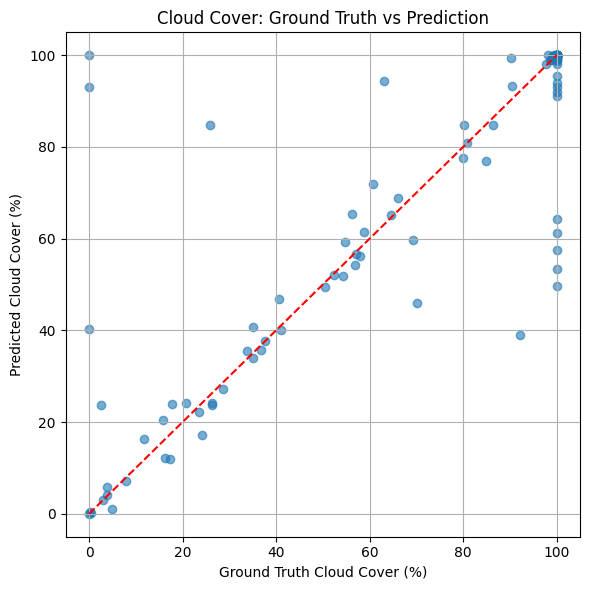

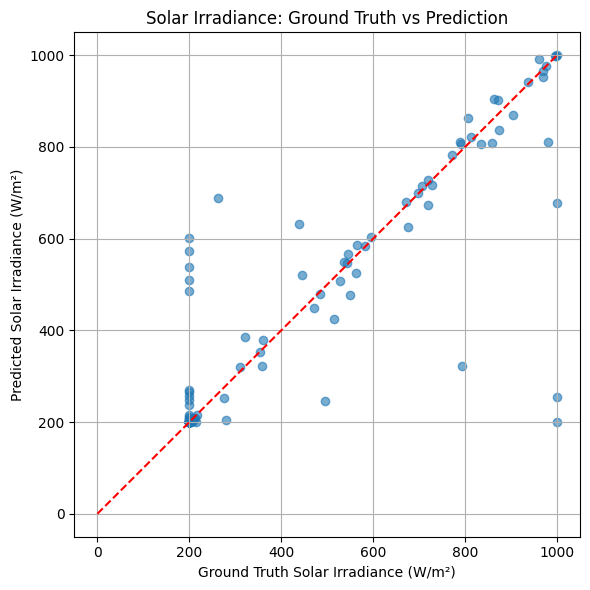

In [36]:
import matplotlib.pyplot as plt

I_MAX = 1000.0  # same value used in irradiance function

# ===============================
# Scatter 1 — Cloud Cover  (%)
# ===============================
plt.figure(figsize=(6, 6))
plt.scatter(gt_cloud_list, pr_cloud_list, alpha=0.6)
plt.plot([0, 100], [0, 100], color="red", linestyle="--")   # perfect-fit line
plt.xlabel("Ground Truth Cloud Cover (%)")
plt.ylabel("Predicted Cloud Cover (%)")
plt.title("Cloud Cover: Ground Truth vs Prediction")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"D:\Documents\AEC\FInal Year Project\unet\output_20\R_scatter.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ===============================
# Scatter 2 — Irradiance (W/m²)
# ===============================
plt.figure(figsize=(6, 6))
plt.scatter(gt_irr_list, pr_irr_list, alpha=0.6)
plt.plot([0, I_MAX], [0, I_MAX], color="red", linestyle="--")  # perfect-fit line
plt.xlabel("Ground Truth Solar Irradiance (W/m²)")
plt.ylabel("Predicted Solar Irradiance (W/m²)")
plt.title("Solar Irradiance: Ground Truth vs Prediction")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"D:\Documents\AEC\FInal Year Project\unet\output_20\I_scatter.png",
            dpi=300, bbox_inches="tight")
plt.show()


## testing only 1 image having B2348

Model loaded.
Cloud cover = 96.26%


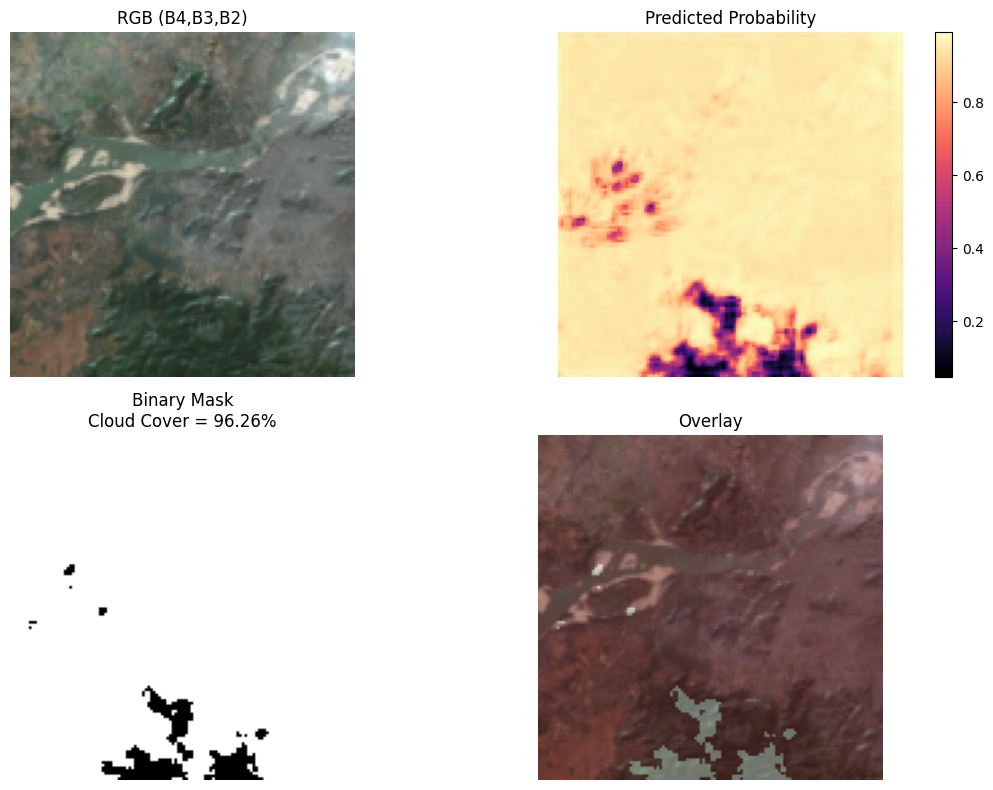

In [62]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model


# -------------------------
# CONFIG
# -------------------------
IMG = r"C:\Users\matin\Downloads\S2_Guwahati_Jan2022_B2B3B4B8_fixed.tif"
MODEL = r"keras_unet_cloud_20epoch_128img.h5"
IMG_SIZE = 128
THRESHOLD = 0.5


# -------------------------
# iou metric
# -------------------------
def iou(y_true, y_pred):
    y_pred = K.clip(y_pred, 0, 1)
    inter = K.sum(y_true * y_pred)
    union = K.sum(y_true + y_pred) - inter
    return (inter + 1e-7) / (union + 1e-7)


# -------------------------
# load model
# -------------------------
model = load_model(MODEL, custom_objects={"iou": iou})
print("Model loaded.")


# -------------------------
# load & preprocess S2 bands
# -------------------------
with rasterio.open(IMG) as src:

    B2 = src.read(1, out_shape=(IMG_SIZE, IMG_SIZE),
                  resampling=Resampling.bilinear).astype(np.float32)
    B3 = src.read(2, out_shape=(IMG_SIZE, IMG_SIZE),
                  resampling=Resampling.bilinear).astype(np.float32)
    B4 = src.read(3, out_shape=(IMG_SIZE, IMG_SIZE),
                  resampling=Resampling.bilinear).astype(np.float32)
    B8 = src.read(4, out_shape=(IMG_SIZE, IMG_SIZE),
                  resampling=Resampling.bilinear).astype(np.float32)

# -------- THIS IS THE IMPORTANT PART --------
# Sentinel-2 SR reflectance scale = 0–10000
X = np.stack([B2, B3, B4, B8], axis=-1) / 10000.0
X = np.clip(X, 0, 1)     # keep clean

# RGB just for plotting
rgb = np.stack([B4, B3, B2], axis=-1)
rgb /= max(rgb.max(), 1e-6)
# --------------------------------------------


# -------------------------
# predict
# -------------------------
prob = model.predict(np.expand_dims(X, 0), verbose=0)[0, ..., 0]
mask = (prob > THRESHOLD).astype(np.uint8)

cloud_percent = mask.mean() * 100
print(f"Cloud cover = {cloud_percent:.2f}%")

# -------------------------
# visualize
# -------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("RGB (B4,B3,B2)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(prob, cmap="magma")
plt.title("Predicted Probability")
plt.colorbar()
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(mask, cmap="gray")
plt.title(f"Binary Mask\nCloud Cover = {cloud_percent:.2f}%")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(rgb)
plt.imshow(mask, cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


In [64]:
import rasterio
import numpy as np

with rasterio.open(IMG) as s:
    for i,name in zip(range(1,5),["B2","B3","B4","B8"]):
        b = s.read(i)
        print(name, "min:", float(b.min()), "max:", float(b.max()), "mean:", float(b.mean()))


B2 min: 243.0 max: 3448.0 mean: 1047.7421565459977
B3 min: 310.0 max: 3924.0 mean: 1166.0576563435068
B4 min: 219.0 max: 4340.0 mean: 1086.0586460654883
B8 min: 395.0 max: 7979.0 mean: 2102.7949257039454


In [8]:
import os
import random
import numpy as np
import tensorflow as tf
import rasterio
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model

# -------------------------
# CONFIG
# -------------------------
ROOT = r"D:\Documents\AEC\16gb data\archive (1)\data"
LABEL_DIR = os.path.join(ROOT, "train_labels")
FEATURE_DIR = os.path.join(ROOT, "train_features")

IMG_SIZE = 128
THRESHOLD = 0.5
N_SAMPLES = 10
RANDOM_SEED = 42

SAVE_DIR = r"D:\Documents\AEC\FInal Year Project\unet\output_30"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------
# METRIC & MODEL
# -------------------------
def iou(y_true, y_pred):
    y_pred = K.clip(y_pred, 0, 1)
    inter = K.sum(y_true * y_pred)
    union = K.sum(y_true + y_pred) - inter
    return (inter + 1e-7) / (union + 1e-7)

model = load_model("keras_unet_cloud_30epochfix_128img.h5",
                   custom_objects={"iou": iou})

# -------------------------
# HELPERS
# -------------------------
def load_sample(chip_id):
    feature_dir = os.path.join(FEATURE_DIR, chip_id)
    label_path  = os.path.join(LABEL_DIR, f"{chip_id}.tif")

    # --- load bands ---
    bands = []
    for b in ["B02","B03","B04","B08"]:
        with rasterio.open(os.path.join(feature_dir, f"{b}.tif")) as src:
            x = src.read(1).astype(np.float32)
        bands.append(x)

    X = np.stack(bands, axis=-1)
    X /= 65535.0

    # --- load GT mask ---
    with rasterio.open(label_path) as src:
        y = src.read(1).astype(np.float32)

    y = np.expand_dims(y, axis=-1)

    # --- resize ---
    X = tf.image.resize(X, (IMG_SIZE, IMG_SIZE)).numpy()
    y = tf.image.resize(y, (IMG_SIZE, IMG_SIZE)).numpy()

    return X, y


def cloud_cover_ratio(mask):
    return mask.mean() * 100.0


def solar_irradiance_from_cloud(mask, I_max=1000.0, alpha=0.8):
    cloud_ratio = cloud_cover_ratio(mask) / 100.0
    irradiance = I_max * (1 - alpha * cloud_ratio)
    irradiance = max(irradiance, 0)
    return cloud_ratio * 100, irradiance


# -------------------------
# LOAD CHIP IDS
# -------------------------
all_chip_ids = sorted([
    d for d in os.listdir(FEATURE_DIR)
    if os.path.isdir(os.path.join(FEATURE_DIR, d))
])

random.seed(RANDOM_SEED)
chip_ids = random.sample(all_chip_ids, N_SAMPLES)

print(f"Selected {len(chip_ids)} chip IDs.")

# -------------------------
# STORAGE
# -------------------------
gt_cloud_list = []
pr_cloud_list = []

gt_irr_list = []
pr_irr_list = []

# -------------------------
# MAIN LOOP
# -------------------------
for idx, chip_id in enumerate(chip_ids):

    try:
        X, y_true = load_sample(chip_id)
    except Exception as e:
        print(f"Skipping {chip_id}: {e}")
        continue

    # --- prediction ---
    Xb = np.expand_dims(X, 0)
    prob = model.predict(Xb, verbose=0)[0, ..., 0]
    y_pred = (prob > THRESHOLD).astype(np.uint8)

    # --- ground truth ---
    y_gt_bin = (y_true[..., 0] > 0.5).astype(np.uint8)

    # --- cloud + irradiance ---
    gt_cloud, gt_I = solar_irradiance_from_cloud(y_gt_bin)
    pr_cloud, pr_I = solar_irradiance_from_cloud(y_pred)

    gt_cloud_list.append(gt_cloud)
    pr_cloud_list.append(pr_cloud)

    gt_irr_list.append(gt_I)
    pr_irr_list.append(pr_I)

    print(
        f"{chip_id} | "
        f"GT Cloud={gt_cloud:.2f}%  Pred Cloud={pr_cloud:.2f}% | "
        f"GT I={gt_I:.1f}  Pred I={pr_I:.1f}"
    )

    # -------------------------
    # ERROR COMPUTATION
    # -------------------------
    error_map = np.abs(y_pred - y_gt_bin)

    fp = (y_pred == 1) & (y_gt_bin == 0)
    fn = (y_pred == 0) & (y_gt_bin == 1)
    tp = (y_pred == 1) & (y_gt_bin == 1)

    error_rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    error_rgb[tp] = [0, 1, 0]   # Green → TP
    error_rgb[fp] = [1, 0, 0]   # Red → FP
    error_rgb[fn] = [0, 0, 1]   # Blue → FN

    # -------------------------
    # RGB IMAGE
    # -------------------------
    rgb = np.stack([X[..., 2], X[..., 1], X[..., 0]], axis=-1)
    rgb = np.clip(rgb / (rgb.max() + 1e-8), 0, 1)

    # -------------------------
    # PLOTTING
    # -------------------------
    plt.figure(figsize=(16, 6))

    # 1. RGB
    plt.subplot(1, 5, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    # 2. Ground Truth
    plt.subplot(1, 5, 2)
    plt.imshow(y_gt_bin, cmap="gray")
    plt.title(f"GT\nCloud={gt_cloud:.1f}%\nI={gt_I:.1f}")
    plt.axis("off")

    # 3. Prediction
    plt.subplot(1, 5, 3)
    plt.imshow(y_pred, cmap="gray")
    plt.title(f"Pred\nCloud={pr_cloud:.1f}%\nI={pr_I:.1f}")
    plt.axis("off")

    # 4. Error Heatmap
    plt.subplot(1, 5, 4)
    plt.imshow(error_map, cmap="hot")
    plt.title("Error Map")
    plt.axis("off")

    # 5. FP / FN Map
    plt.subplot(1, 5, 5)
    plt.imshow(error_rgb)
    plt.title("TP(G) FP(R) FN(B)")
    plt.axis("off")

    plt.tight_layout()

    # -------------------------
    # SAVE
    # -------------------------
    save_path = os.path.join(SAVE_DIR, f"{chip_id}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

# -------------------------
# OPTIONAL SUMMARY PRINT
# -------------------------
print("\nProcessing complete.")

Selected 10 chip IDs.
xpcd | GT Cloud=90.48%  Pred Cloud=99.01% | GT I=276.1  Pred I=208.0
dcuw | GT Cloud=100.00%  Pred Cloud=68.95% | GT I=200.0  Pred I=448.4
apob | GT Cloud=80.16%  Pred Cloud=87.53% | GT I=358.7  Pred I=299.8
kswl | GT Cloud=100.00%  Pred Cloud=99.99% | GT I=200.0  Pred I=200.1
iwmu | GT Cloud=20.67%  Pred Cloud=32.86% | GT I=834.7  Pred I=737.1
hxdd | GT Cloud=0.00%  Pred Cloud=48.95% | GT I=1000.0  Pred I=608.4
duwk | GT Cloud=35.05%  Pred Cloud=51.71% | GT I=719.6  Pred I=586.3
cuqj | GT Cloud=2.53%  Pred Cloud=25.89% | GT I=979.7  Pred I=792.9
ylag | GT Cloud=69.23%  Pred Cloud=61.80% | GT I=446.1  Pred I=505.6
vfgi | GT Cloud=40.95%  Pred Cloud=47.02% | GT I=672.4  Pred I=623.9

Processing complete.
